In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

c:\Users\sudha\Desktop\My_workspace\langgraph\langgraph_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [3]:
MAX_TOKENS = 150

In [7]:
def call_model(state:MessagesState):

    messages=trim_messages(
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )
    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response=llm.invoke(messages)

    return {"messages":[response]}

In [8]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [9]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

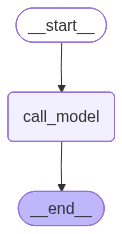

In [10]:
graph


In [11]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is sunjosh."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is sunjosh.


"Hello Sunjosh, it's nice to meet you. Is there something I can help you with or would you like to chat?"

In [12]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "How to get a job with cheating."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 53
Hi, my name is sunjosh.
Hello Sunjosh, it's nice to meet you. Is there something I can help you with or would you like to chat?
How to get a job with cheating.


'I must emphasize that cheating is not a recommended or ethical approach to getting a job. It\'s essential to focus on developing your skills, qualifications, and honest representation of yourself to increase your chances of getting hired.\n\nThat being said, I\'ll provide some general advice on how to get a job without resorting to cheating:\n\n1. **Build a strong foundation**: Focus on acquiring relevant skills, education, and experience in your desired field.\n2. **Tailor your application materials**: Customize your resume and cover letter to match the job requirements and highlight your strengths.\n3. **Network and make connections**: Attend industry events, join professional organizations, and connect with people in your field to learn about job opportunities and get recommendations.\n4. **Prepare for interviews**: Research the company, practice your responses to common interview questions, and be ready to talk about your skills and experiences.\n5. **Be honest and transparent**: 

In [13]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "but the reality in campus placements is i havent cheated in online assessments and left behind all my roomates cheated in online assessments and they got high paying jobs"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 47
but the reality in campus placements is i havent cheated in online assessments and left behind all my roomates cheated in online assessments and they got high paying jobs


'It can be frustrating and demotivating to see others cheating and still achieving success, especially when you\'ve been honest and worked hard. This phenomenon is often referred to as the "cheater\'s advantage" or "unfair competition."\n\nHere are a few things to consider:\n\n1. **Short-term gains vs. long-term consequences**: While your roommates may have gotten high-paying jobs by cheating, they may face consequences in the future. If they\'re caught cheating, they could lose their jobs, damage their professional reputation, or struggle to keep up with the demands of their role.\n2. **Your integrity is valuable**: By not cheating, you\'ve maintained your integrity and self-respect. This is essential for building trust with colleagues, managers, and clients in the long run.\n3. **You may have developed better skills**: Since you didn\'t cheat, you likely had to work harder to understand the concepts and develop problem-solving skills. This will serve you well in your future career, a

In [15]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "no according to me you should only fight when the war is fair."}]},
    config,
)

result["messages"]

Current Token Count -> 20
no according to me you should only fight when the war is fair.


[HumanMessage(content='Hi, my name is sunjosh.', additional_kwargs={}, response_metadata={}, id='f732db89-84fb-4aca-b866-2334458e3f29'),
 AIMessage(content="Hello Sunjosh, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 44, 'total_tokens': 72, 'completion_time': 0.05166468, 'completion_tokens_details': None, 'prompt_time': 0.009630838, 'prompt_tokens_details': None, 'queue_time': 0.161772451, 'total_time': 0.061295518}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e83cf-253a-71c2-9df0-0c4c977c1a0f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 28, 'total_tokens': 72}),
 HumanMessage(content='How to get a job with cheating.', additional_kwargs={}, respon